In [1]:
import pandas as pd

# loading the data
df = pd.read_csv('kaggle raw data/appearances.csv')

# checking shape and preview
print(df.shape)
df.head()

(1706806, 13)


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


In [2]:
df.isna().sum().sort_values(ascending=False)

player_name               6
appearance_id             0
game_id                   0
player_id                 0
player_club_id            0
player_current_club_id    0
date                      0
competition_id            0
yellow_cards              0
red_cards                 0
goals                     0
assists                   0
minutes_played            0
dtype: int64

In [3]:
df = df[df['player_name'].notna()]

In [4]:
# checking for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

# dropping duplicates if any
df = df.drop_duplicates()

Duplicates: 0


In [5]:
# strip strings in object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df = df[df['minutes_played'] >= 0]

In [8]:
df.describe()

,game_id,player_id,player_club_id,player_current_club_id,date,yellow_cards,red_cards,goals,assists,minutes_played
count,1.706800e+06,1.706800e+06,1.706800e+06,1.706800e+06,1706800,1.706800e+06,1.706800e+06,1.706800e+06,1.706800e+06,1.706800e+06
mean,3.166096e+06,2.099741e+05,3.138264e+03,3.991249e+03,2019-01-03 08:03:51.928754176,1.472328e-01,3.783103e-03,9.589466e-02,7.549566e-02,6.906118e+01
min,2.211607e+06,1.000000e+01,1.000000e+00,3.000000e+00,2012-07-03 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.589007e+06,5.840200e+04,2.890000e+02,3.310000e+02,2015-10-20 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.500000e+01
50%,3.080787e+06,1.495770e+05,8.260000e+02,9.030000e+02,2019-01-04 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
75%,3.621597e+06,3.066680e+05,2.441000e+03,2.696000e+03,2022-04-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+01
max,4.572898e+06,1.380876e+06,1.103020e+05,1.103020e+05,2025-04-10 00:00:00,2.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,1.480000e+02
std,6.651208e+05,1.944009e+05,8.315812e+03,1.084707e+04,NaN,3.653799e-01,6.139050e-02,3.309354e-01,2.855619e-01,2.999314e+01


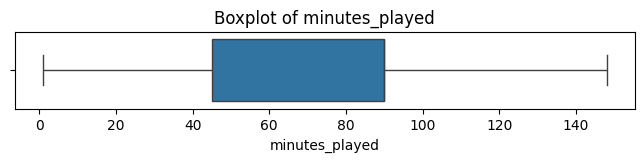

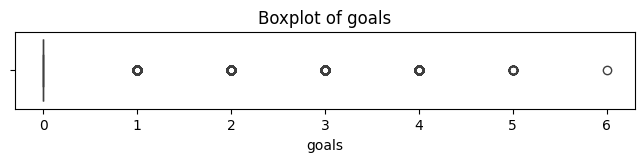

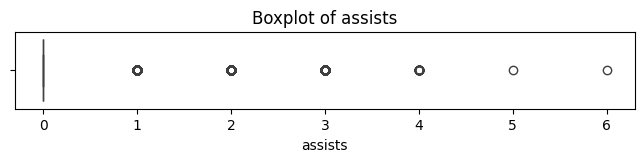

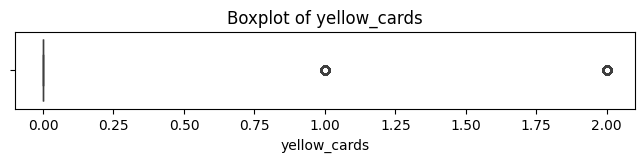

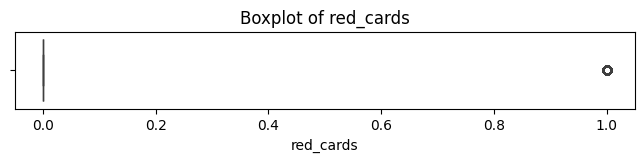

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['minutes_played', 'goals', 'assists', 'yellow_cards', 'red_cards']
for col in numerical_cols:
    plt.figure(figsize=(8, 1))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [10]:
# cap goals and assists to a max of 4
df['goals'] = df['goals'].clip(upper=4)
df['assists'] = df['assists'].clip(upper=4)

# cap minutes played (e.g. max 120)
df = df[df['minutes_played'] <= 120]

In [11]:
print(df.dtypes)

appearance_id                     object
game_id                            int64
player_id                          int64
player_club_id                     int64
player_current_club_id             int64
date                      datetime64[ns]
player_name                       object
competition_id                    object
yellow_cards                       int64
red_cards                          int64
goals                              int64
assists                            int64
minutes_played                     int64
dtype: object


In [12]:
# goal involvement: a key performance metric
df['goal_involvement'] = df['goals'] + df['assists']

# discipline metric (card count)
df['card_count'] = df['yellow_cards'] + df['red_cards']

In [13]:
df = df[[
    'appearance_id', 'player_id', 'player_name', 'game_id', 'date',
    'player_club_id', 'player_current_club_id', 'competition_id',
    'minutes_played', 'goals', 'assists', 'goal_involvement',
    'yellow_cards', 'red_cards', 'card_count'
]]

In [14]:
df['assists'].value_counts().sort_index()

assists
0    1587305
1     110746
2       8169
3        539
4         38
Name: count, dtype: int64

In [15]:
df['minutes_played'].value_counts().sort_index()

minutes_played
1      26580
2       7861
3       8610
4       9152
5       9752
       ...  
116       20
117       25
118       30
119       31
120     8222
Name: count, Length: 120, dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler
# making a backup before any modifications
df_unscaled = df.copy()

# then cap raw values on df 
df['goals'] = df['goals'].clip(upper=4)
df['assists'] = df['assists'].clip(upper=4)
df = df[df['minutes_played'] <= 120]

# then scaling
scaler = StandardScaler()
df[['minutes_played', 'goals', 'assists']] = scaler.fit_transform(df[['minutes_played', 'goals', 'assists']])

In [17]:
print(df_unscaled['goals'].value_counts().sort_index())
print(df_unscaled['assists'].value_counts().sort_index())
print(df_unscaled['minutes_played'].value_counts().sort_index())

goals
0    1560439
1     130984
2      13631
3       1572
4        171
Name: count, dtype: int64
assists
0    1587305
1     110746
2       8169
3        539
4         38
Name: count, dtype: int64
minutes_played
1      26580
2       7861
3       8610
4       9152
5       9752
       ...  
116       20
117       25
118       30
119       31
120     8222
Name: count, Length: 120, dtype: int64


In [18]:
df.reset_index(drop=True, inplace=True)

In [19]:
df.dtypes

appearance_id                     object
player_id                          int64
player_name                       object
game_id                            int64
date                      datetime64[ns]
player_club_id                     int64
player_current_club_id             int64
competition_id                    object
minutes_played                   float64
goals                            float64
assists                          float64
goal_involvement                   int64
yellow_cards                       int64
red_cards                          int64
card_count                         int64
dtype: object

In [20]:
# saving to CSV for modeling or backup
df.to_csv("cleaned_appearances.csv", index=False)